In [1]:
%%capture
!pip install indiafactorlibrary

In [2]:
# Notebook: 07_fi_fund_analysis
# Series:   pyIndiaFactorInvesting
# Data:     Invespar Indian Factor Library (FF6 + FI factors) + FI fund sample
# Run in:   Colab / Binder / local
# Author:   Rajan Raju

# 07 — Fixed Income Factor Exposures of Indian Debt Funds

How much of a debt fund's return comes from taking duration risk, and how much from credit risk? The equity side of this series uses six factors to decompose fund returns into systematic components. This notebook does the same for fixed income, using two factor proxies — TERM_IN and CREDIT_IN — that capture the two primary sources of return variation in the Indian bond market: interest-rate sensitivity and credit spread sensitivity. Five anonymised Indian debt mutual funds, spanning the spectrum from a gilt fund to a credit risk fund, illustrate how the decomposition changes across mandates.

**What you will leave with**
- An understanding of TERM_IN and CREDIT_IN as synthetic benchmark-exposure proxies for duration and credit risk
- Full-sample factor exposures (betas, alpha, R²) for five funds spanning the gilt-to-credit-risk spectrum
- How β_TERM and β_CREDIT differ systematically across debt fund categories
- Rolling factor attribution showing how duration and credit tilts vary over time
- A concrete illustration of why a lower R² for credit risk funds does not mean the model is wrong

**Prerequisites:** Notebooks 03/03a (regression toolkit), 05 (fund decomposition framework)

In [3]:
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col

sys.path.insert(0, str(Path('.').resolve().parent))

import indiafactorlibrary as ifl
from src.data import load_fi_factors, load_fi_fund_sample

In [4]:
# ── ifl setup ────────────────────────────────────────────
_lib = ifl.IndiaFactorLibrary()
_lib.session.headers.update({'User-Agent': (
    'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) '
    'AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36')})

def read(name):
    return _lib.read(name)

# ── Load FF6 (for RF) and FI factors via indiafactorlibrary ──────────────
ff6_raw = read('FF6')[0];  ff6_raw.index = pd.to_datetime(ff6_raw.index)
ff6_raw.index = ff6_raw.index.to_period('M').to_timestamp('M')
ff6  = ff6_raw / 100

fi_raw = read('fi_factors')[0];  fi_raw.index = pd.to_datetime(fi_raw.index)
fi_raw.index = fi_raw.index.to_period('M').to_timestamp('M')
fi   = fi_raw / 100

# ── Load fund returns from bundled sample ────────────────────────────
funds = load_fi_fund_sample()   # Fund_A … Fund_E — decimal, Jun 2012 – Mar 2025


In [5]:
# ── Align on common period ────────────────────────────────────────────
idx    = fi.index.intersection(funds.index).intersection(ff6.index)
fi_a   = fi.loc[idx]
fund_a = funds.loc[idx]
rf     = ff6.loc[idx, 'RF']
er     = fund_a.subtract(rf, axis=0)   # excess returns: fund – RF

fund_cols   = fund_a.columns.tolist()
factor_cols = ['TERM_IN', 'CREDIT_IN']
start_s = idx.min().strftime('%b %Y')
end_s   = idx.max().strftime('%b %Y')
n_obs   = len(idx)
print(f"Period  : {start_s} – {end_s}  ({n_obs} months)")
print(f"Factors : TERM_IN, CREDIT_IN  (synthetic benchmark-exposure proxies, Raju 2026 SSRN 6419998)")
print(f"Funds   : {fund_cols}")


Period  : Jun 2012 – Mar 2025  (154 months)
Factors : TERM_IN, CREDIT_IN  (synthetic benchmark-exposure proxies, Raju 2026 SSRN 6419998)
Funds   : ['Fund_A', 'Fund_B', 'Fund_C', 'Fund_D', 'Fund_E']


## 1  What Fixed Income Factors Capture

### 1a  Two Sources of Return in the Indian Bond Market

Bond fund returns come primarily from two sources. The first is **duration risk**: holding long-maturity bonds that are sensitive to changes in interest rates. When yields fall, long-duration bonds appreciate; when yields rise, they lose value. The second is **credit risk**: holding bonds from issuers that carry a spread over sovereign yields — typically corporate or financial issuers. When credit spreads narrow, these bonds outperform G-Sec; when spreads widen, they underperform.

TERM_IN and CREDIT_IN are **synthetic benchmark-exposure proxies** that capture these two sources.

### 1b  TERM_IN: The Duration Factor

TERM_IN is the excess return proxy on a 10-year Government Securities (G-Sec) benchmark exposure over a 3-month T-Bill carry. It is constructed from LSEG Datastream benchmark yield data using modified duration and convexity — the same bond mathematics that practitioners use to estimate price sensitivity. A fund with a high beta on TERM_IN carries substantial interest-rate sensitivity: its returns move closely with 10-year G-Sec returns beyond what the T-bill rate provides.

### 1c  CREDIT_IN: The Credit Spread Factor

CREDIT_IN is the excess return proxy on a 10-year AAA corporate benchmark exposure over the 10-year G-Sec benchmark exposure. It captures the return contribution of holding investment-grade corporate paper relative to sovereign paper of similar maturity. A fund with a high beta on CREDIT_IN earns returns that co-move with AAA corporate spread movements.

**An important limitation to carry forward.** Both TERM_IN and CREDIT_IN are constructed from benchmark yields, not from directly observed total return indices. The corporate benchmark is a composite model-valued yield in a relatively less liquid market segment. The resulting series should be interpreted as synthetic benchmark-exposure proxies, not as directly investable factor returns. Downstream regressions are descriptive diagnostics of comovement, not structural identification of underlying risk premia (Raju 2026, SSRN 6419998).

### 1d  The Model

Each fund's monthly excess return (fund return minus the risk-free rate RF) is regressed on the two factor proxies:

$$r_t^{\text{excess}} = \alpha + \beta_{\text{TERM}} \cdot \text{TERM\_IN}_t + \beta_{\text{CREDIT}} \cdot \text{CREDIT\_IN}_t + \varepsilon_t$$

The intercept $\alpha$ captures the return unexplained by the two factors — it absorbs management costs, any omitted systematic exposures, and residual skill if present. Standard errors are heteroskedasticity- and autocorrelation-consistent (Newey-West HAC, maxlags = 4).

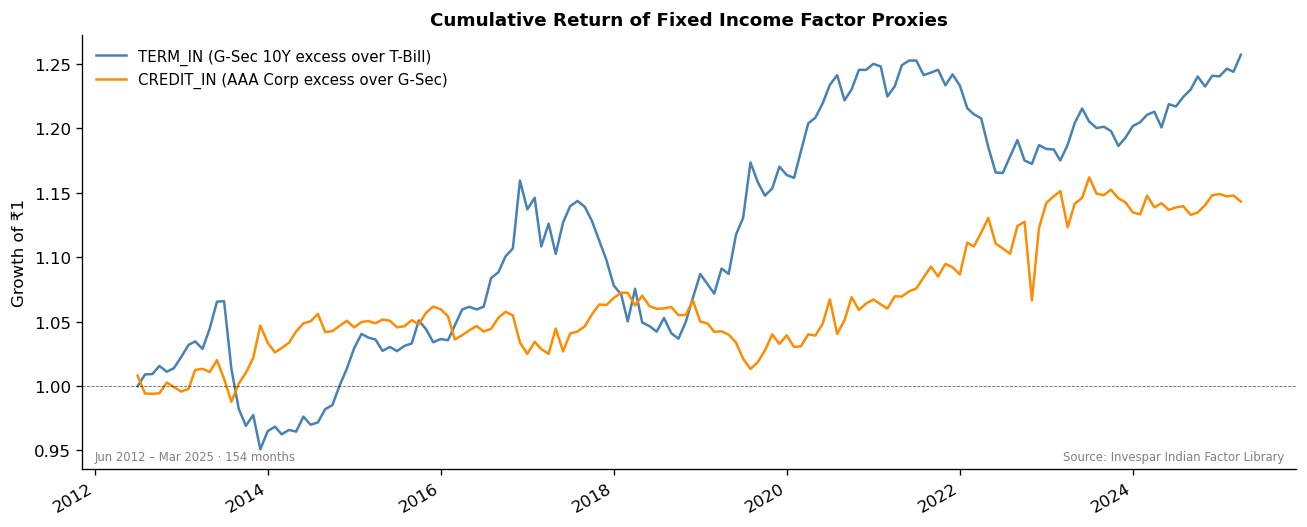

In [6]:
# ── Cumulative return: TERM_IN and CREDIT_IN ─────────────────────────────────
period_str = f"{start_s} \u2013 {end_s} \u00b7 {n_obs} months"
source_str = 'Source: Invespar Indian Factor Library'

fig, ax = plt.subplots(figsize=(11, 4.5), dpi=120)
for col, clr, lbl in zip(['TERM_IN', 'CREDIT_IN'],
                          ['steelblue', 'darkorange'],
                          ['TERM_IN (G-Sec 10Y excess over T-Bill)', 'CREDIT_IN (AAA Corp excess over G-Sec)']):
    s = fi_a[col].dropna()
    ax.plot(s.index, (1 + s).cumprod().values, label=lbl, linewidth=1.5, color=clr)
ax.axhline(1, color='black', linewidth=0.5, linestyle='--', alpha=0.6)
ax.set_title('Cumulative Return of Fixed Income Factor Proxies', fontsize=11, fontweight='bold')
ax.set_ylabel('Growth of \u20b91', fontsize=10)
ax.legend(fontsize=9, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.annotate(period_str, xy=(0.01, 0.02), xycoords='axes fraction', fontsize=7, color='grey')
ax.annotate(source_str, xy=(0.99, 0.02), xycoords='axes fraction', fontsize=7, color='grey', ha='right')
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 2  The Five-Fund Sample

The five anonymised funds cover the main debt-fund mandate categories in India.

| Label | Mandate | What the fund primarily holds |
|-------|---------|-------------------------------|
| Fund A | Gilt | Central government securities, long duration |
| Fund B | Dynamic Bond | Sovereign and near-sovereign paper, active duration management |
| Fund C | Short Duration | Investment-grade paper, short remaining maturity |
| Fund D | Corporate Bond | High-quality (AA+ / AAA) corporate paper, medium duration |
| Fund E | Credit Risk | Lower-rated corporate paper seeking spread income |

All five funds have complete monthly return histories from June 2012 through March 2025 (154 months) with no missing observations. The sample period encompasses several major events in Indian fixed income markets: the taper tantrum (mid-2013), demonetisation (November 2016), the IL&FS default and credit crisis (September 2018), the COVID-19 stress episode (March 2020), and the post-pandemic rate cycle. The funds are anonymised; no fund names, AMC names, or identifiers are disclosed.

In [7]:
# ── Annualised summary statistics for five funds ─────────────────────────────
def _stats(series, name):
    ann_mean = series.mean() * 12
    ann_vol  = series.std() * np.sqrt(12)
    sharpe   = ann_mean / ann_vol if ann_vol != 0 else np.nan
    skew     = series.skew()
    cum      = (1 + series).cumprod()
    mdd      = ((cum - cum.cummax()) / cum.cummax()).min()
    return pd.Series({'Ann. Return': ann_mean, 'Ann. Vol': ann_vol,
                      'Sharpe': sharpe, 'Skewness': skew, 'Max Drawdown': mdd}, name=name)

stats_df = pd.DataFrame([_stats(fund_a[c], c) for c in fund_cols])
disp = stats_df.copy()
for col in ['Ann. Return', 'Ann. Vol', 'Max Drawdown']:
    disp[col] = disp[col].map('{:.1%}'.format)
for col in ['Sharpe', 'Skewness']:
    disp[col] = disp[col].map('{:.2f}'.format)
print(f"Fund Summary Statistics  ({start_s} \u2013 {end_s} \u00b7 {n_obs} months)")
print(disp.to_string())

Fund Summary Statistics  (Jun 2012 – Mar 2025 · 154 months)
       Ann. Return Ann. Vol Sharpe Skewness Max Drawdown
Fund_A        8.2%     4.4%   1.87    -0.25        -8.4%
Fund_B        7.9%     2.6%   3.06    -0.17        -2.0%
Fund_C        7.7%     1.8%   4.27    -0.41        -2.2%
Fund_D        7.9%     2.0%   3.97    -0.75        -2.5%
Fund_E        7.9%     1.6%   4.99    -1.09        -2.0%


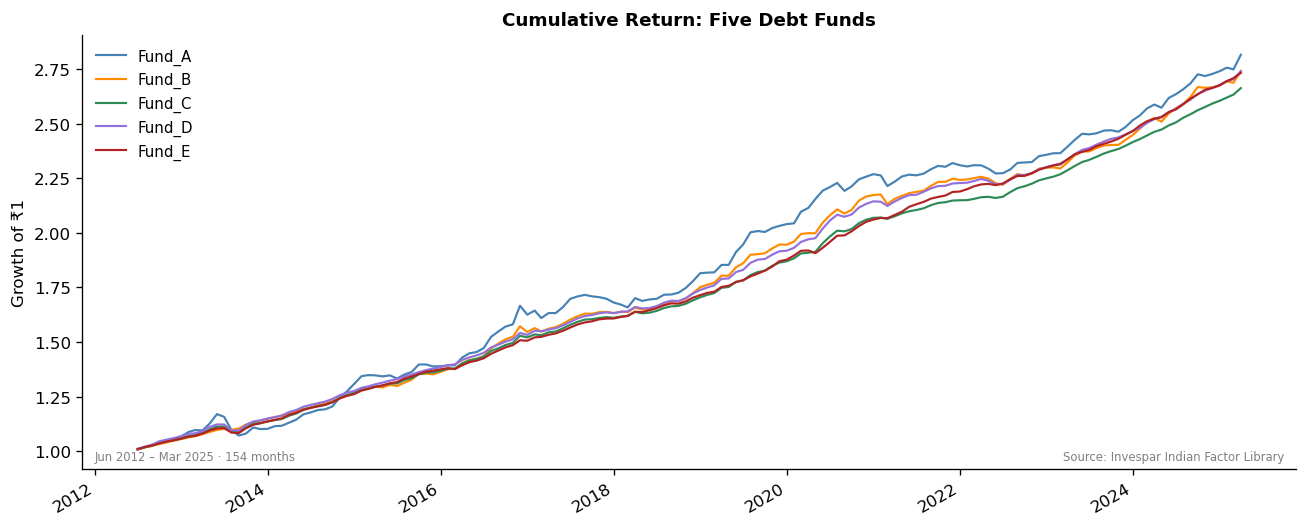

In [8]:
# ── Cumulative return: five funds ────────────────────────────────────────────
colors     = ['steelblue', 'darkorange', 'seagreen', 'mediumpurple', 'firebrick']
fig, ax = plt.subplots(figsize=(11, 4.5), dpi=120)
for col, clr in zip(fund_cols, colors):
    cum = (1 + fund_a[col]).cumprod()
    ax.plot(cum.index, cum.values, label=col, color=clr, linewidth=1.3)
ax.set_title('Cumulative Return: Five Debt Funds', fontsize=11, fontweight='bold')
ax.set_ylabel('Growth of \u20b91', fontsize=10)
ax.legend(fontsize=9, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.annotate(period_str, xy=(0.01, 0.02), xycoords='axes fraction', fontsize=7, color='grey')
ax.annotate(source_str, xy=(0.99, 0.02), xycoords='axes fraction', fontsize=7, color='grey', ha='right')
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 3  Full-Sample Factor Exposures

### 3a  Running the Regressions

We regress each fund's monthly excess return on TERM_IN and CREDIT_IN over the full sample. The same two-factor model is applied to all five funds — even the gilt fund (Fund A) and the short duration fund (Fund C), where CREDIT_IN exposure is expected to be near zero. Using the same model for all five funds lets the coefficients themselves reveal the differences across mandates, rather than having the model structure do the sorting. HAC standard errors (Newey-West, maxlags = 4) correct for any serial correlation in residuals.

In [9]:
# ── OLS with HAC SEs: fund excess return ~ TERM_IN + CREDIT_IN ──────────────
import statsmodels.formula.api as smf

reg_results = {}
for col in fund_cols:
    df_reg = fi_a[factor_cols].assign(Y=er[col]).dropna()
    reg_results[col] = smf.ols('Y ~ TERM_IN + CREDIT_IN', data=df_reg).fit(
        cov_type='HAC', cov_kwds={'maxlags': 4}
    )


In [10]:
# ── Compact attribution table ────────────────────────────────────────────────
rows = []
for col, m in reg_results.items():
    alpha_m   = m.params['Intercept']
    alpha_ann = alpha_m * 12
    rows.append({
        'Fund':          col,
        'α ann. (%)': f'{alpha_ann*100:.2f}',
        't(α)':       f'{m.tvalues["Intercept"]:+.2f}',
        'β_TERM':     f'{m.params["TERM_IN"]:.3f}',
        't(TERM)':       f'{m.tvalues["TERM_IN"]:+.2f}',
        'β_CREDIT':   f'{m.params["CREDIT_IN"]:.3f}',
        't(CREDIT)':     f'{m.tvalues["CREDIT_IN"]:+.2f}',
        'R²':         f'{m.rsquared:.3f}',
        'N':             int(m.nobs),
    })
attr_df = pd.DataFrame(rows).set_index('Fund')
print(f"Factor Exposures  ({start_s} – {end_s})")
print(f"HAC SE (Newey-West, maxlags=4) · dependent variable: fund excess return (fund return − RF)")
print(attr_df.to_string())


Factor Exposures  (Jun 2012 – Mar 2025)
HAC SE (Newey-West, maxlags=4) · dependent variable: fund excess return (fund return − RF)
       α ann. (%)   t(α) β_TERM t(TERM) β_CREDIT t(CREDIT)     R²    N
Fund                                                                  
Fund_A       0.08  +0.16  0.885  +13.07    0.167     +1.86  0.781  154
Fund_B       0.76  +1.53  0.438   +7.22    0.071     +1.52  0.555  154
Fund_C       0.74  +2.42  0.311   +9.57    0.078     +1.55  0.574  154
Fund_D       0.88  +2.67  0.339   +9.88    0.109     +1.94  0.570  154
Fund_E       1.08  +2.92  0.230   +6.20    0.084     +1.61  0.403  154


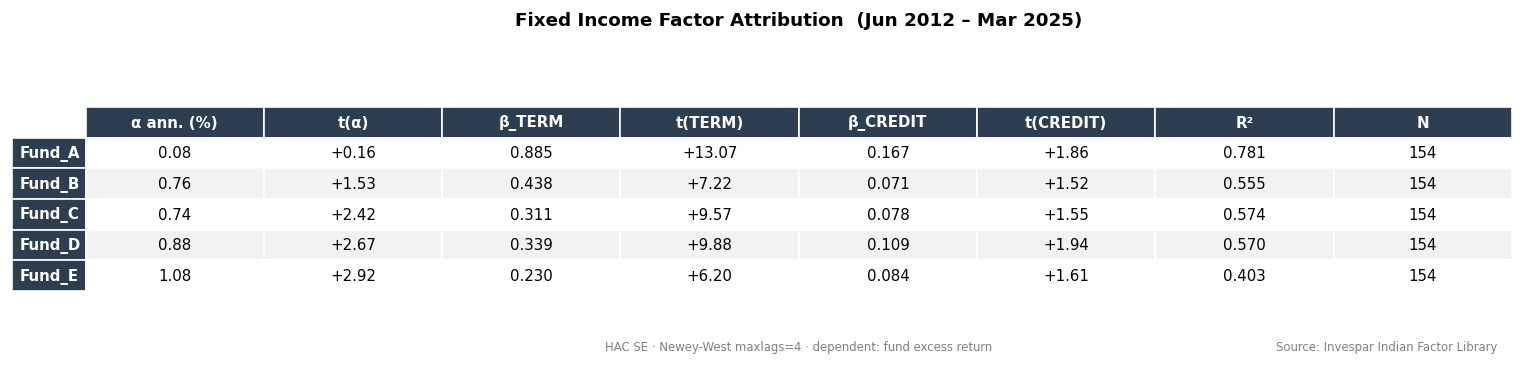

In [11]:
# ── Attribution table as a figure ───────────────────────────────────────────
col_labels = list(attr_df.columns)
row_labels = list(attr_df.index)
cell_vals  = attr_df.values.tolist()

fig_h = max(1.8, 0.45 * (len(row_labels) + 2))
fig, ax = plt.subplots(figsize=(min(13, 1.6 * len(col_labels)), fig_h), dpi=120)
ax.axis('off')

table = ax.table(
    cellText=cell_vals,
    rowLabels=row_labels,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.45)

for (row, col), cell in table.get_celld().items():
    if row == 0 or col == -1:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#f2f2f2')
    cell.set_edgecolor('white')

ax.set_title(f'Fixed Income Factor Attribution  ({start_s} \u2013 {end_s})',
             fontsize=11, fontweight='bold', pad=12)
ax.annotate('HAC SE \u00b7 Newey-West maxlags=4 \u00b7 dependent: fund excess return',
            xy=(0.5, 0.01), xycoords='axes fraction', fontsize=7, color='grey', ha='center')
ax.annotate(source_str, xy=(0.99, 0.01), xycoords='axes fraction', fontsize=7, color='grey', ha='right')
fig.tight_layout()
plt.show()

## 4  Reading the Exposures

### 4a  β_TERM_IN Across Fund Categories

Fund A, the gilt fund, shows the largest TERM_IN loading in the table. This is expected: a fund that holds almost exclusively 10-year G-Sec bonds will track a 10-year G-Sec return proxy closely, and the data bears this out. Fund B (dynamic bond) and Fund C (short duration) show progressively smaller TERM_IN loadings, reflecting shorter effective durations across those mandates. Fund D (corporate bond) and Fund E (credit risk) show lower TERM_IN loadings still — their mandates permit shorter-duration or credit-tilted instruments that are less sensitive to long-end rate moves.

### 4b  β_CREDIT_IN Signals Credit Orientation

Fund D (corporate bond) and Fund E (credit risk) are the two funds that show a meaningful CREDIT_IN loading. For Fund B and Fund C, CREDIT_IN is small and not statistically significant at conventional levels, consistent with mandates focused on shorter-duration or near-sovereign instruments with limited credit spread exposure. Fund A, the gilt fund, shows a borderline result: the CREDIT_IN loading is positive but marginal, possibly reflecting correlation between the AAA spread cycle and long-end G-Sec yields, or the small fraction of non-sovereign holdings that some gilt funds carry within regulatory limits. For Fund D and Fund E, the positive CREDIT_IN loading shows that their return variation co-moves with AAA corporate spread movements.

### 4c  R² Variation and What It Means

The model explains a larger fraction of Fund A's return variance than Fund E's. Fund A holds long-duration sovereign bonds; TERM_IN — itself a 10-year G-Sec proxy — is a natural match for that return stream. Fund E holds lower-rated corporate paper; the AAA corporate spread proxy (CREDIT_IN) does not fully capture the idiosyncratic credit risk of sub-AAA or unrated issuers. A lower R² here does not mean the model is wrong: it means the model's two systematic factors explain a smaller share of what drives that fund's returns. The unexplained residual reflects credit events, manager positioning, and issuer-specific risk not captured in the AAA benchmark. The same pattern — lower R² for credit-oriented funds — is consistent across a broader fund universe when mandates are compared.

### 4d  The Intercept

The monthly intercept, annualised and shown in the first column of the table, represents the return not explained by TERM_IN and CREDIT_IN. It absorbs management costs (typically 0.5–2% per annum for Indian debt funds), any systematic exposures not captured by the two factors, and residual manager skill if present. Distinguishing these components requires either a cost-adjusted test or comparison against a fund's disclosed expense ratio — an analysis beyond the scope of this notebook.

## 5  Rolling Factor Attribution

### 5a  Why Full-Sample Betas Miss Time-Variation

A full-sample regression assumes each fund's factor exposures are constant over the entire history. In practice, debt fund managers adjust duration actively — some by mandate (dynamic bond funds), others in response to interest-rate views or regulatory requirements. Credit risk funds may also shift their quality profile depending on available spreads and market conditions.

Rolling regressions reveal this time variation. Each 36-month rolling window produces a snapshot of TERM_IN and CREDIT_IN exposures at that point in time; the rolling series shows how those exposures have shifted. The window is the same 36-month period used throughout this series for comparability.

Rolling OLS (standard, not HAC) is used within each window: the window is short enough that the autocorrelation correction is less critical, and standard OLS produces cleaner rolling estimates. The series is labelled by the endpoint date of each window.

The first rolling point appears in June 2015 (36 months after June 2012), and the last in March 2025 — giving 119 rolling observations per fund.

In [12]:
# ── 36-month rolling OLS (standard per window, labelled by endpoint) ─────────
def _rolling_regression(y_series, X_df, window=36):
    idx = y_series.index.intersection(X_df.index)
    y   = y_series.loc[idx].dropna()
    X   = pd.concat([pd.Series(1.0, index=y.index, name='const'),
                     X_df.loc[y.index]], axis=1)
    out = {}
    for t in range(window, len(y) + 1):
        yw, Xw = y.iloc[t-window:t], X.iloc[t-window:t]
        try:
            f = sm.OLS(yw, Xw).fit()
            out[y.index[t-1]] = {**dict(zip(X.columns, f.params)), 'R2': f.rsquared}
        except Exception:
            out[y.index[t-1]] = {c: np.nan for c in list(X.columns) + ['R2']}
    return pd.DataFrame(out).T

roll = {col: _rolling_regression(er[col], fi_a[factor_cols], window=36)
        for col in fund_cols}

print("Rolling window: 36 months  (standard OLS per window, labelled by endpoint)")
r0 = roll[fund_cols[0]]
print(f"Range: {r0.index.min().strftime('%b %Y')} \u2013 {r0.index.max().strftime('%b %Y')}"
      f"  ({len(r0)} rolling points)")

Rolling window: 36 months  (standard OLS per window, labelled by endpoint)
Range: May 2015 – Mar 2025  (119 rolling points)


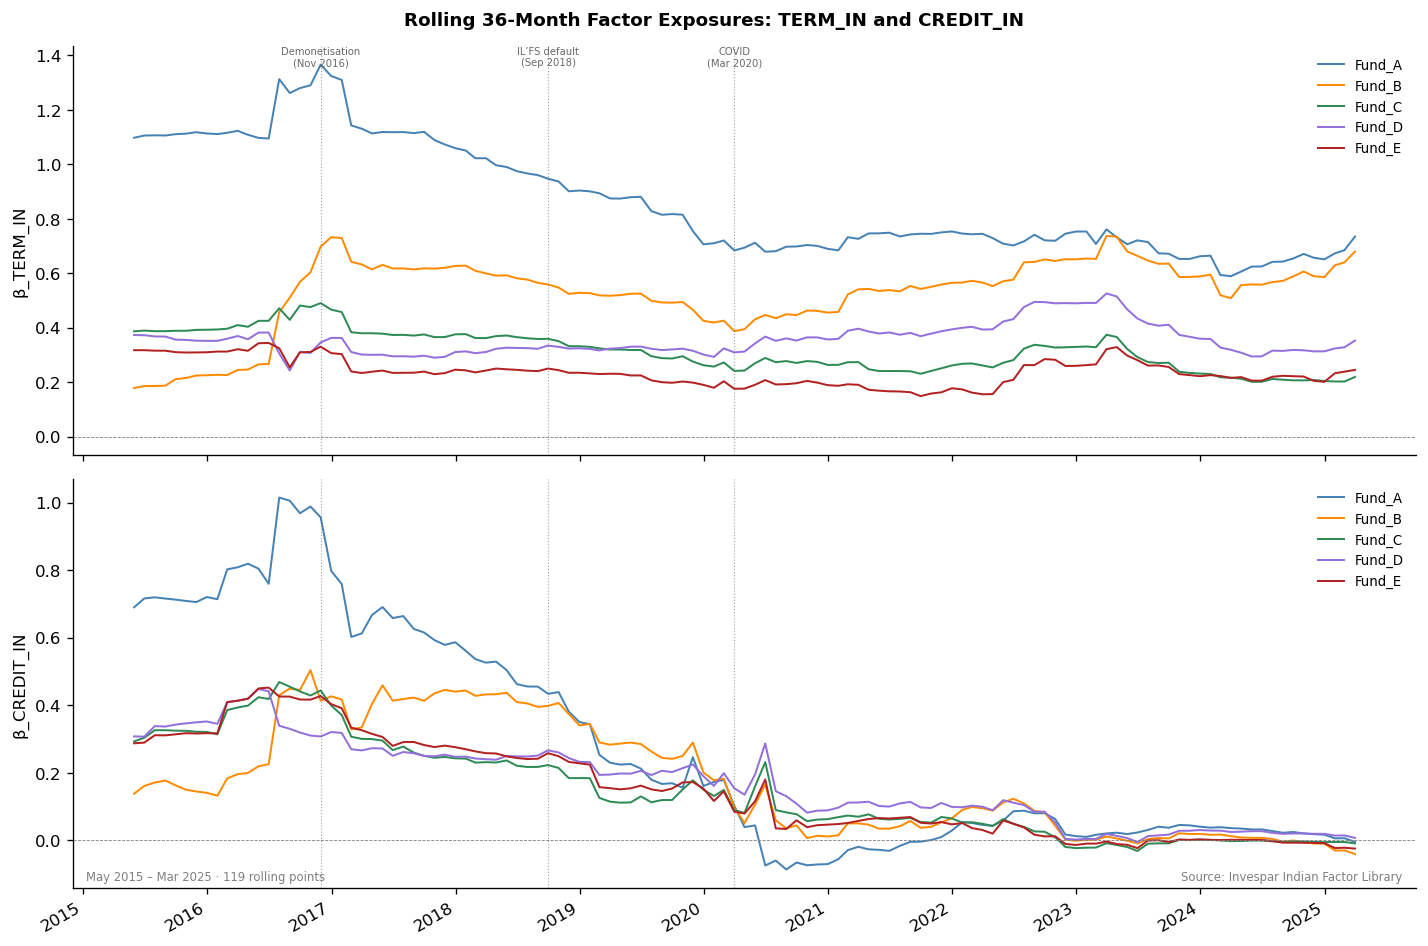

In [13]:
# ── 2-panel rolling beta chart ───────────────────────────────────────────────
colors_r = ['steelblue', 'darkorange', 'seagreen', 'mediumpurple', 'firebrick']

event_dates = {
    'Demonetisation\n(Nov 2016)': pd.Timestamp('2016-11-30'),
    'IL\u2019FS default\n(Sep 2018)':  pd.Timestamp('2018-09-30'),
    'COVID\n(Mar 2020)':          pd.Timestamp('2020-03-31'),
}

roll_start = roll[fund_cols[0]].index.min().strftime('%b %Y')
roll_end   = roll[fund_cols[0]].index.max().strftime('%b %Y')
roll_n     = len(roll[fund_cols[0]])
roll_period = f"{roll_start} \u2013 {roll_end} \u00b7 {roll_n} rolling points"

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), dpi=120, sharex=True)

for col, clr in zip(fund_cols, colors_r):
    r = roll[col]
    ax1.plot(r.index, r['TERM_IN'],   label=col, color=clr, linewidth=1.2)
    ax2.plot(r.index, r['CREDIT_IN'], label=col, color=clr, linewidth=1.2)

for ax in (ax1, ax2):
    ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
    for lbl, dt in event_dates.items():
        ax.axvline(dt, color='dimgrey', linewidth=0.7, linestyle=':', alpha=0.6)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=8, frameon=False, loc='upper right')

for lbl, dt in event_dates.items():
    ax1.annotate(lbl, xy=(dt, 1), xycoords=('data', 'axes fraction'),
                fontsize=6, color='dimgrey', ha='center', va='top')

fig.suptitle('Rolling 36-Month Factor Exposures: TERM_IN and CREDIT_IN',
             fontsize=11, fontweight='bold')
ax1.set_ylabel('\u03b2_TERM_IN', fontsize=10)
ax2.set_ylabel('\u03b2_CREDIT_IN', fontsize=10)
ax2.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax2.xaxis.get_major_locator()))
ax2.annotate(roll_period, xy=(0.01, 0.02), xycoords='axes fraction', fontsize=7, color='grey')
ax2.annotate(source_str,  xy=(0.99, 0.02), xycoords='axes fraction', fontsize=7, color='grey', ha='right')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 6  What the Rolling Picture Shows

### 6a  Duration Stability vs Flexibility

**Fund A (Gilt).** The rolling β_TERM_IN is consistently the highest in the upper panel throughout the sample and remains relatively stable. Gilt funds invest almost exclusively in central government securities; they cannot reduce duration by shifting to credit. The data shows that this structural constraint produces a persistently high and relatively stable TERM_IN exposure over time.

**Fund B (Dynamic Bond).** The rolling β_TERM_IN varies more over the sample than Fund A. Dynamic bond fund managers have an explicit mandate to adjust portfolio duration in response to their rate outlook. The wider range of rolling betas in the data reflects this active management latitude.

**Fund C (Short Duration).** The rolling β_TERM_IN is the lowest of the three duration-oriented funds and remains stable at a low level. Short duration funds are mandated to hold instruments with short remaining maturities; their rate sensitivity is structurally constrained.

### 6b  Credit Exposure Over Time

**Fund D (Corporate Bond) and Fund E (Credit Risk).** Both funds show positive rolling β_CREDIT_IN in the lower panel for most of the sample, confirming their structural exposure to the AAA corporate spread cycle. The exposure is not constant: it varies with market conditions and portfolio positioning. Note that β_CREDIT_IN for Fund E — the credit risk fund — can turn volatile or negative in periods of broad credit stress, reflecting the mismatch between the AAA proxy and the lower-rated paper that credit risk funds hold.

### 6c  Three Events Worth Noting

Three vertical markers on the chart indicate notable events in the Indian fixed income market:

- **Demonetisation (November 2016):** The Reserve Bank of India's liquidity injection into the banking system in response to note cancellation drove a sharp fall in short-term yields. The effect is visible as a temporary spike in TERM_IN exposures for duration-oriented funds.

- **IL\u2019FS default (September 2018):** The collapse of Infrastructure Leasing & Financial Services triggered a broad repricing of credit risk in the Indian corporate bond market. Spread widening compressed returns on corporate paper relative to sovereign paper, and the effect shows in the rolling CREDIT_IN betas of Funds D and E.

- **COVID-19 (March 2020):** A simultaneous flight to safety and liquidity stress episode. Rate volatility affected all duration-sensitive funds; credit spreads widened sharply. The episode is visible as a discontinuity in rolling betas across all five funds.

## 7  What We Established

| Concept | What the data shows | Where it matters |
|---------|---------------------|------------------|
| TERM_IN | Excess return proxy for 10Y G-Sec exposure over T-Bill carry; constructed from benchmark yields, not directly observable total returns | Identifying interest-rate sensitivity in any debt fund |
| CREDIT_IN | Excess return proxy for AAA corporate spread over G-Sec; captures credit spread co-movement, limited to investment-grade benchmark | Detecting credit tilt in mandate-compliant corporate and spread funds |
| β_TERM spectrum | Gilt funds show the highest and most stable loadings; short duration funds the lowest; dynamic bond funds show the widest time-variation | Comparing rate sensitivity across categories without holdings data |
| β_CREDIT signal | Meaningful only for corporate bond and credit risk funds; near-zero for gilt and sovereign funds — consistent with mandates | Distinguishing duration-oriented from credit-oriented mandates |
| R² variation | Higher for gilt funds (factor is a close match), lower for credit risk funds (AAA proxy misses sub-AAA idiosyncratic risk) | Interpreting R² as model-fit, not mandate quality |
| Rolling attribution | Duration tilts shift with manager action and market regime; credit tilts respond to the spread cycle and stress episodes | Detecting style drift and timing of mandate changes |

**Next:** This notebook is the final notebook in the series that covers the tools of factor analysis applied to Indian markets. The fixed income factors used here are described in detail in Raju (2026, SSRN 6419998); the equity factors in notebooks 00\u201306 are sourced from the Invespar Indian Factor Library.

## References

Raju, R. (2022). Factor Exposures and Alpha of Indian Equity Schemes. SSRN Working Paper 4107950.

Raju, R. (2026). Fixed Income Factors for India: Term and AAA Corporate Spread Proxies from Benchmark Yield Data. SSRN Working Paper 6419998.

Invespar (2026). India Factor Library. Accessed May 2026.